In [1]:
%load_ext autoreload
%autoreload 2

from paper_utils import *

In [56]:
from constants import COLORS, TEXTWIDTH, GOLDEN_RATIO, PRETTY_NAMES

In [2]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
# 167019 / 1gxo9oef --> original generate_answers run trivia-qa
# 167127 / 1sn9kt0u --> compute uncertainties trivia-qa
# 167194 / ceumvx4j --> final analyze run
# --> ablation 3 -- 15: 167201, 167209 -- 167213, 167215--167220
    'ceumvx4j': 'trivia_qa-15',
    'kyps0l5c': 'trivia_qa-3',
    'lmgl9uqw': 'trivia_qa-4',
    'h907rs39': 'trivia_qa-5',
    '4c75wp2w': 'trivia_qa-6',
    'w9s4glzs': 'trivia_qa-7',
    '37it7nr9': 'trivia_qa-8',
    'acf22lqm': 'trivia_qa-9',
    'rfud6pex': 'trivia_qa-10',
    'wlzopa8b': 'trivia_qa-11',
    'ko4lthz7': 'trivia_qa-12',
    'm2pey1cf': 'trivia_qa-13',
    'ozwofq1z': 'trivia_qa-14',

# 167018 / dqtye228 --> original generate_answers run bioasq
# 167272 / i855qzau --> compute uncertainties bioasq ---> restrict to 200 generations because of cost. push comes to shove, can re-run again.
# 167327 / m9c2ipfs --> final analyze run
# ablation 3 -- 5: 167367 -- 167378
    'm9c2ipfs': 'bioasq-15',
    'zu0gvsvv': 'bioasq-3',
    'penhh9on': 'bioasq-4',
    '7s5gabz4': 'bioasq-5',
    'eogcnegj': 'bioasq-6',
    'nhog7yk5': 'bioasq-7',
    '3d6obogq': 'bioasq-8',
    '9n1pxwse': 'bioasq-9',
    '93z4l6jz': 'bioasq-10',
    'c9cg7ocd': 'bioasq-11',
    's1dozf1c': 'bioasq-12',
    'zldi7tma': 'bioasq-13',
    'd88w9ul1': 'bioasq-14',

# 167020 / uvfbxm6d --> original generate_answers run squad
# 167178 / uh7pp7iu --> compute uncertainties squad
# 167275 / 0tit46iz --> final analyze run

# ablation 3--15: 167276, 167277 -- 167287
    '0tit46iz': 'squad-15',
    '0b9ugqc6': 'squad-3',
    '2k3n5vwu': 'squad-4',
    'wmuerxk7': 'squad-5',
    '28q6db61': 'squad-6',
    'fsbt6khu': 'squad-7',
    '8ehbkd99': 'squad-8',
    'v1i8nxv1': 'squad-9',
    'f8lk2529': 'squad-10',
    'y30wx2tv': 'squad-11',
    'y46ezmtv': 'squad-12',
    '5f47uiac': 'squad-13',
    '4m9htci6': 'squad-14',
}
# runs at other num_generations --> launch only after initial compute_uncertainties is run



# }

all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [3]:
# OOD for p_ik
p_ik_runs = {
    'sd3ihole': 'trivia_qa-bioasq',
    'lcobj81w': 'trivia_qa-squad',
    'jxr5kvnm': 'bioasq-trivia_qa',
    'b857ibdw': 'bioasq-squad',
    'wtp516v5': 'squad-trivia_qa',
    'g56g0fxh': 'squad-bioasq',
}
p_ik_configs, p_ik_results = {}, {}

for wandb_id in p_ik_runs:
    p_ik_results[wandb_id], p_ik_configs[wandb_id] = restore_file(wandb_id)

model,bioasq,squad,trivia_qa
dataset,,,
10,0.545,0.3475,0.8675
11,0.545,0.3475,0.8675
12,0.545,0.3475,0.8675
13,0.545,0.3475,0.8675
14,0.545,0.3475,0.8675
15,0.545,0.3475,0.8675
3,0.545,0.3475,0.8675
4,0.545,0.3475,0.8675
5,0.545,0.3475,0.8675


Text(0, 0.5, 'accuracy')

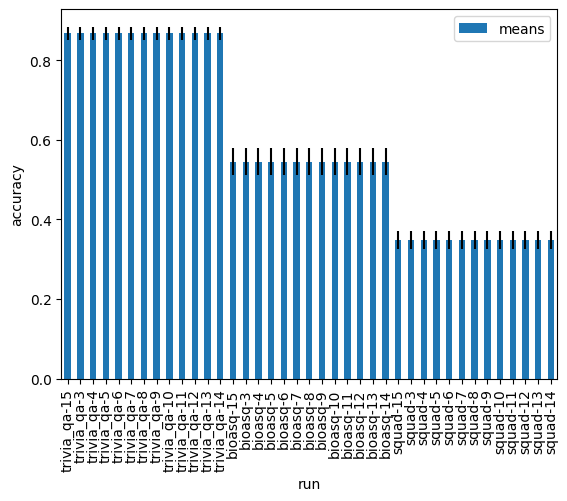

In [4]:
perfdf, pdfs, all_runs = get_perf_df(runs)
all_runs['num_generations'] = all_runs.run.map(lambda x: int(x.split('-')[1]))
all_runs['dataset'] = all_runs.run.map(lambda x: x.split('-')[0])

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

In [5]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(p_ik_runs, all_results=p_ik_results)
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['eval_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[0])
pik_all_runs['train_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[1])

model,bioasq,squad,trivia_qa
dataset,,,
bioasq,NaN,0.3475,0.8675
squad,0.545,NaN,0.8675
trivia_qa,0.545,0.3475,NaN


In [70]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

main_methods = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_ik', 'p_false', ]

text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)


Text(0.5, 80.7222222222222, 'Number of generations')

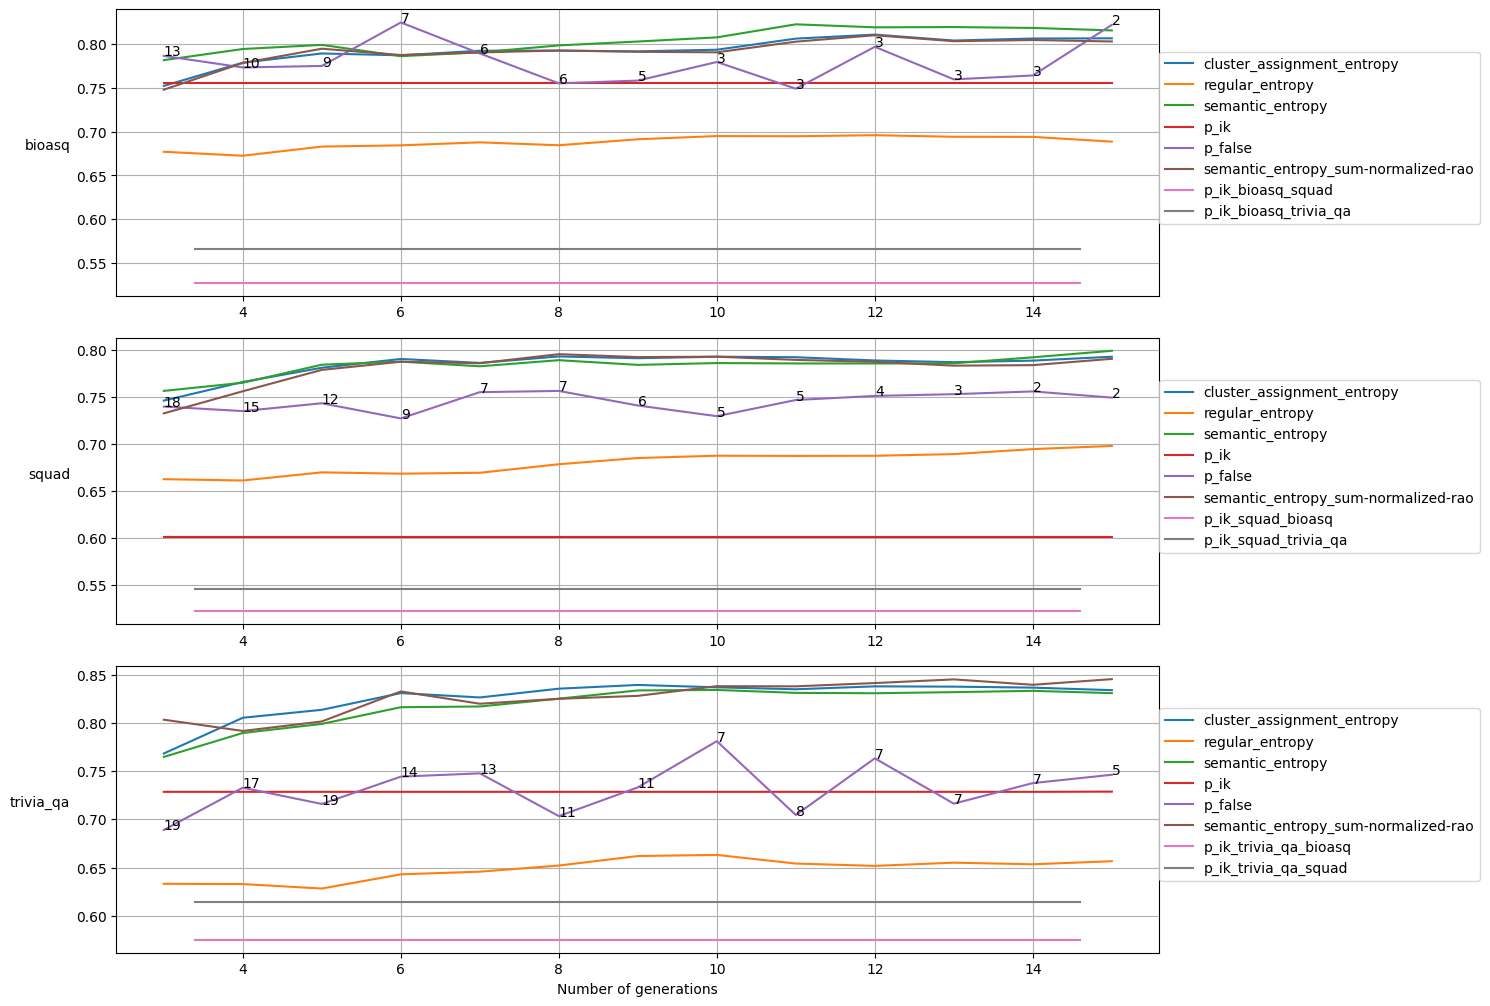

In [9]:
metric = 'AUROC'

df2 = deepcopy(all_runs)
df2 = df2[df2.metric == metric]
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']

fig, axes = plt.subplots(df2.dataset.nunique(), figsize=(15, 10))

if df2.dataset.nunique() == 1:
    axes = [axes]

methods = main_methods

for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):
    ax.set_ylabel(dataset, rotation=0, ha='right')
    ax.grid()
    for m, method in enumerate(methods):
        df3 = gdf[gdf.method == method]
        x, y, h, l = df3.num_generations.values, df3.means.values, df3.low.values, df3.high.values
        idxs = np.argsort(x)
        x, y, h, l = x[idxs], y[idxs], h[idxs], l[idxs]
        ax.plot(x, y, label=method)
        # ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
        if method == 'p_false':
            ids = df3.wandb_id.values[idxs]
            if dataset == 'squad':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            elif dataset == 'trivia_qa':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 5})['value'] for wid in ids]
            elif dataset == 'bioasq':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            else:
                raise
            for xpos, ypos, text in zip(x, y, num_p_true):
                ax.text(xpos, ypos, text)

    xlims = ax.get_xlim()
    x = [xlims[0]+1, xlims[1]-1]
    for train_dataset, pik_tmp in pik_all_runs.set_index('metric').loc[metric].set_index('eval_dataset').loc[dataset].groupby('train_dataset'):
        m, l, h = get_vals2(pik_tmp.iloc[0])
        ax.plot(x, [m, m], label=f'p_ik_{dataset}_{train_dataset}')
        # ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
    ax.set_xlim(*xlims)

    ax.legend(loc=(1, 0.25))

print("text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)")
plt.tight_layout()
axes[-1].set_xlabel('Number of generations')

/tmp/ipykernel_1262960/3163734652.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):


text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)


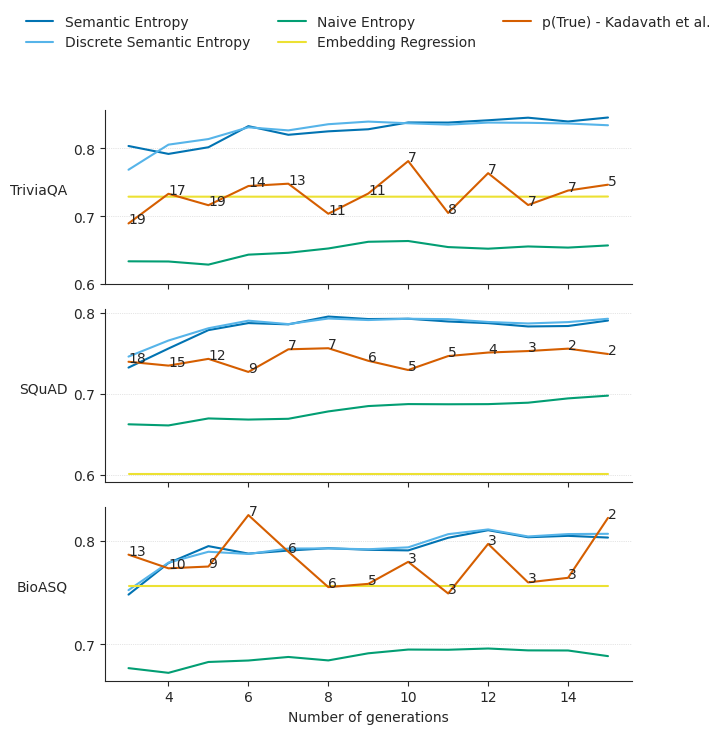

In [83]:
metric = 'AUROC'



df2 = deepcopy(all_runs)
df2 = df2[df2.metric == metric]

fig, axes = plt.subplots(df2.dataset.nunique(), figsize=(1.4*TEXTWIDTH, 1.4*TEXTWIDTH), sharex=True)
sns.set_style("ticks")

if df2.dataset.nunique() == 1:
    axes = [axes]

methods = main_methods
desired_order = ['trivia_qa', 'squad', 'bioasq']
df2['dataset'] = pd.Categorical(df2['dataset'], categories=desired_order, ordered=True)
df2 = df2.sort_values('dataset')
# methods.remove('semantic_entropy')
first = True
for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):
    ax.set_ylabel(pretty_names[dataset], rotation=0, ha='right')
    for m, method in enumerate(methods):
        df3 = gdf[gdf.method == method]
        x, y, h, l = df3.num_generations.values, df3.means.values, df3.low.values, df3.high.values
        idxs = np.argsort(x)
        x, y, h, l = x[idxs], y[idxs], h[idxs], l[idxs]
        ax.plot(x, y, label=pretty_names[method], color=COLORS[method])

        # Special behaviour for writing number of generations used for few-shotting
        if method == 'p_false':
            ids = df3.wandb_id.values[idxs]
            if dataset == 'squad':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            elif dataset == 'trivia_qa':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 5})['value'] for wid in ids]
            elif dataset == 'bioasq':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            else:
                raise
            for xpos, ypos, text in zip(x, y, num_p_true):
                ax.text(xpos, ypos, text)

    sns.despine()
    x_lims, y_lims = ax.get_xlim(), ax.get_ylim()
    ax.set_yticks(np.arange(np.round(y_lims[0] * 10) / 10,y_lims[1], 0.1))
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle=':', linewidth=0.5)
    # for train_dataset, pik_tmp in pik_all_runs.set_index('metric').loc[metric].set_index('eval_dataset').loc[dataset].groupby('train_dataset'):
    #     m, l, h = get_vals2(pik_tmp.iloc[0])
    #     ax.plot([3,15], [m, m], label=f'p_ik_{dataset}_{train_dataset}')
    if first:
        first = False
        ax.legend(bbox_to_anchor=(.5, 1.45), loc='center', ncols=3, frameon=False)

print("text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)")
plt.tight_layout()
axes[-1].set_xlabel('Number of generations')
plt.savefig("/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_sentence_n_generations_ablation.pdf", bbox_inches='tight', pad_inches=0.02)


These results are with llama-2 for generation and entailment calculation!